# ch240 — Calculus in High Dimensions

**Part VII — Calculus | Advanced Experiment 10**

> "In low dimensions, intuition is your ally. In high dimensions, it becomes your adversary."

Everything we have built in Part VII — gradients, Hessians, Taylor series, integration —
was demonstrated in 1D or 2D. Machine learning operates in dimensions ranging from
hundreds to hundreds of millions. This chapter confronts what changes, what survives,
and what breaks when calculus moves to high-dimensional spaces.

This is the capstone of Part VII. It ties together the full arc from ch201 to ch239
and points directly into Part IX (Statistics & Data Science) and Part VI (Linear Algebra).

**What you will build:**
1. A numerical demonstration of the curse of dimensionality
2. Volume concentration: where does a unit ball's volume live?
3. Gradient behavior in high dimensions — norm growth, direction noise
4. The Johnson-Lindenstrauss lemma, implemented and verified
5. Why random projections preserve inner products (and therefore cosine similarity)

**Prerequisites:** ch208 (automatic differentiation), ch209 (gradient intuition),
ch211 (multivariable functions), ch217 (second derivatives / Hessians),
ch219 (Taylor series), ch224 (Monte Carlo integration), ch236 (vector calculus)

## 1. The Curse of Dimensionality

The phrase was coined by Richard Bellman in 1957. The core phenomenon: as dimension $d$
grows, geometric intuitions from $\mathbb{R}^2$ and $\mathbb{R}^3$ fail — often catastrophically.

We will measure three manifestations:

**1a. Volume of the unit ball vanishes**

The volume of a unit ball in $d$ dimensions is:
$$V_d = \frac{\pi^{d/2}}{\Gamma(d/2 + 1)}$$

As $d \to \infty$, $V_d \to 0$. Almost all volume concentrates in a thin shell near
the surface.

**1b. All points become equidistant**

For $n$ points drawn uniformly from $[0,1]^d$, the ratio:
$$\frac{\text{max distance} - \text{min distance}}{\text{min distance}} \to 0$$
as $d \to \infty$. Nearest-neighbor search becomes meaningless.

**1c. Diagonal corners**

In $d$ dimensions, a unit hypercube has $2^d$ corners. The diagonal has length
$\sqrt{d}$ — it grows without bound while the edge length stays 1. The geometry
stretches in unexpected directions.

*(Builds directly on ch224 — Monte Carlo Integration for volume estimation)*

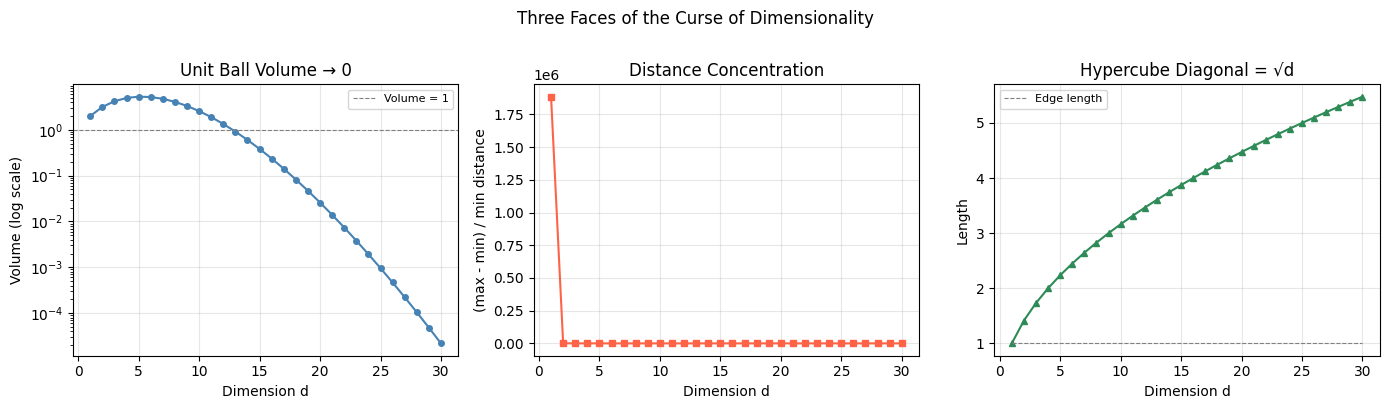

d=1  volume=2.0000  ratio=1885360.900  diag=1.000
d=10 volume=2.550164  ratio=5.998  diag=3.162
d=30 volume=2.19e-05  ratio=1.743  diag=5.477


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from matplotlib.gridspec import GridSpec

rng = np.random.default_rng(42)

# --- 1a. Volume of unit ball as dimension grows ---
dims = np.arange(1, 31)

def unit_ball_volume(d):
    return np.pi**(d/2) / gamma(d/2 + 1)

volumes = [unit_ball_volume(d) for d in dims]

# --- 1b. Distance concentration ---
n_points = 500
max_min_ratios = []

for d in dims:
    pts = rng.uniform(0, 1, size=(n_points, d))
    # pairwise squared distances (vectorized)
    sq = np.sum(pts**2, axis=1)
    D2 = sq[:, None] + sq[None, :] - 2 * pts @ pts.T
    np.fill_diagonal(D2, np.inf)
    dists = np.sqrt(np.maximum(D2, 0))
    np.fill_diagonal(dists, np.inf)
    d_min = dists.min()
    np.fill_diagonal(dists, 0)
    d_max = dists.max()
    ratio = (d_max - d_min) / (d_min + 1e-12)
    max_min_ratios.append(ratio)

# --- 1c. Diagonal length ---
diag_lengths = np.sqrt(dims)

fig = plt.figure(figsize=(14, 4))
gs = GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.semilogy(dims, volumes, 'o-', color='steelblue', markersize=4, linewidth=1.5)
ax1.axhline(1, color='gray', linestyle='--', linewidth=0.8, label='Volume = 1')
ax1.set_xlabel('Dimension d')
ax1.set_ylabel('Volume (log scale)')
ax1.set_title('Unit Ball Volume → 0')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(dims, max_min_ratios, 's-', color='tomato', markersize=4, linewidth=1.5)
ax2.set_xlabel('Dimension d')
ax2.set_ylabel('(max - min) / min distance')
ax2.set_title('Distance Concentration')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.plot(dims, diag_lengths, '^-', color='seagreen', markersize=4, linewidth=1.5)
ax3.plot(dims, np.ones_like(dims), '--', color='gray', linewidth=0.8, label='Edge length')
ax3.set_xlabel('Dimension d')
ax3.set_ylabel('Length')
ax3.set_title('Hypercube Diagonal = √d')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle('Three Faces of the Curse of Dimensionality', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('ch240_curse_of_dimensionality.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"d=1  volume={unit_ball_volume(1):.4f}  ratio={max_min_ratios[0]:.3f}  diag={diag_lengths[0]:.3f}")
print(f"d=10 volume={unit_ball_volume(10):.6f}  ratio={max_min_ratios[9]:.3f}  diag={diag_lengths[9]:.3f}")
print(f"d=30 volume={unit_ball_volume(30):.2e}  ratio={max_min_ratios[29]:.3f}  diag={diag_lengths[29]:.3f}")

## 2. Volume Concentration in a Shell

If the curse says volume vanishes from the ball — where does it go?
It concentrates in a thin shell near the surface.

For a ball of radius 1 and a shell of thickness $\epsilon$:
$$\frac{V(\text{shell})}{V(\text{ball})} = 1 - (1 - \epsilon)^d$$

For any fixed $\epsilon > 0$, this ratio $\to 1$ as $d \to \infty$.

**Implication:** A randomly drawn point from a high-dimensional ball is almost
certainly near the surface. This is why initializing neural network weights as
small random numbers is non-trivial — the effective geometry of the weight space
is not what low-dimensional intuition suggests.

*(This connects to ch213 — Optimization Landscapes: the loss landscape in high
dimensions has far more saddle points than local minima, because in each
direction there is roughly equal probability of curvature being positive or negative.)*

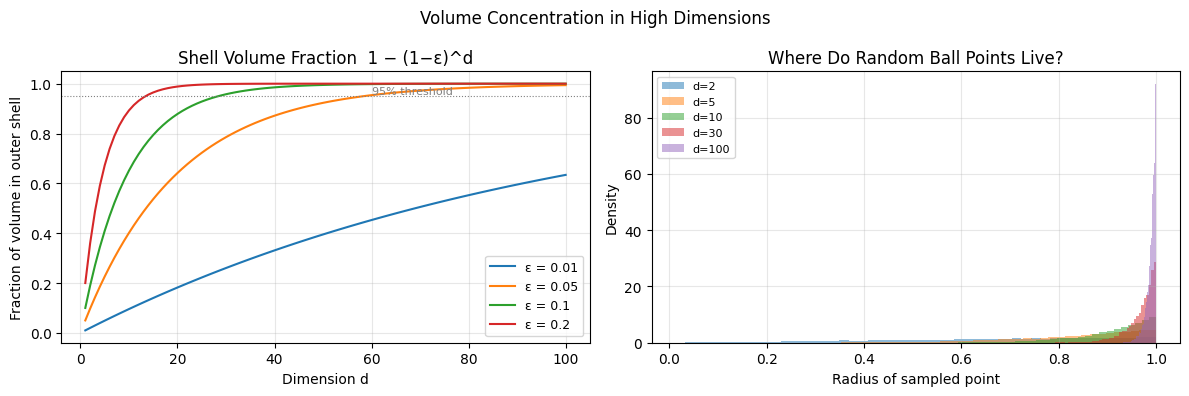

For ε=0.05: 95% of volume is in outer shell by d=59
Verified: in d=100, median sample radius = 0.9929 (max = 1.0)


In [2]:
epsilon = 0.05  # shell thickness = 5% of radius
dims_fine = np.arange(1, 101)
shell_fraction = 1 - (1 - epsilon)**dims_fine

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for eps in [0.01, 0.05, 0.1, 0.2]:
    frac = 1 - (1 - eps)**dims_fine
    ax.plot(dims_fine, frac, label=f'ε = {eps}', linewidth=1.5)
ax.set_xlabel('Dimension d')
ax.set_ylabel('Fraction of volume in outer shell')
ax.set_title('Shell Volume Fraction  1 − (1−ε)^d')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8)
ax.text(60, 0.96, '95% threshold', fontsize=8, color='gray')

# Monte Carlo verification: sample from d-ball, measure radius
ax = axes[1]
for d in [2, 5, 10, 30, 100]:
    # Sample from unit ball: Gaussian + normalize + scale by U^(1/d)
    n = 10000
    z = rng.standard_normal((n, d))
    norms = np.linalg.norm(z, axis=1, keepdims=True)
    u = rng.uniform(0, 1, (n, 1))**(1/d)
    pts = z / norms * u
    radii = np.linalg.norm(pts, axis=1)
    ax.hist(radii, bins=50, alpha=0.5, density=True, label=f'd={d}')

ax.set_xlabel('Radius of sampled point')
ax.set_ylabel('Density')
ax.set_title('Where Do Random Ball Points Live?')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Volume Concentration in High Dimensions', fontsize=12)
plt.tight_layout()
plt.savefig('ch240_shell_concentration.png', dpi=120, bbox_inches='tight')
plt.show()

d_cross = np.argmax(shell_fraction > 0.95) + 1
print(f"For ε=0.05: 95% of volume is in outer shell by d={d_cross}")
print(f"Verified: in d=100, median sample radius = {np.median(radii):.4f} (max = 1.0)")

## 3. Gradient Behavior in High Dimensions

The gradient $\nabla f(\mathbf{x}) \in \mathbb{R}^d$ carries information about
the direction of steepest ascent *(introduced in ch209 — Gradient Intuition)*.

In high dimensions, two important effects emerge:

**Effect 1: Gradient norm grows with dimension**

For a function $f(\mathbf{x}) = \frac{1}{2}\|\mathbf{x}\|^2$, the gradient is
$\nabla f = \mathbf{x}$. At a random point $\mathbf{x} \sim \mathcal{N}(0, I_d)$:
$$\mathbb{E}[\|\nabla f\|] = \mathbb{E}[\|\mathbf{x}\|] \approx \sqrt{d}$$

This is why learning rate schedules must account for the dimensionality of the model.
A learning rate that works for a 10-parameter model may diverge in a 10M-parameter model.

**Effect 2: Angle between successive gradients → 90°**

For stochastic gradients computed on different mini-batches in high dimensions,
the angle between them concentrates around 90°. This is a consequence of the
concentration of measure — nearly all pairs of random unit vectors in $\mathbb{R}^d$
are approximately orthogonal.

*(Connects to ch238 — SGD Theory, where mini-batch gradient noise was analyzed
probabilistically. See also ch238 for the CLT connection.)*

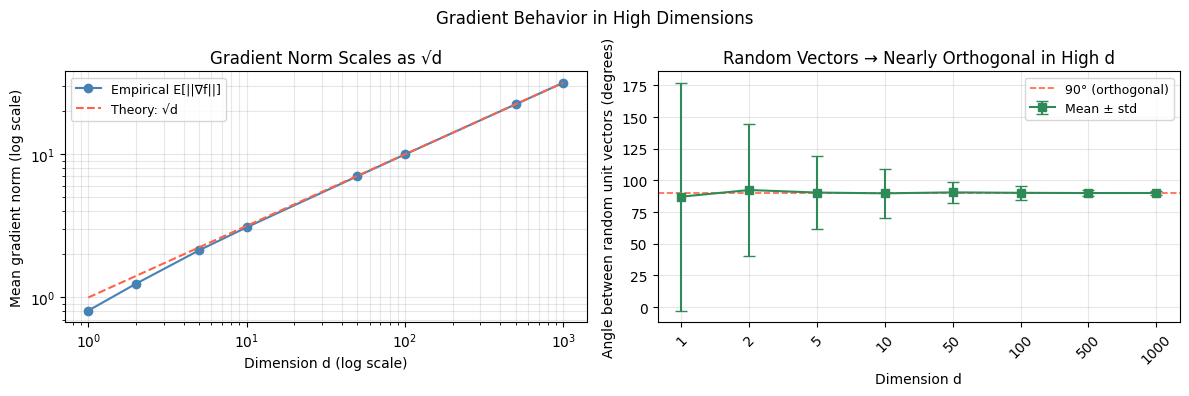

Dimension  | Empirical norm | Theory √d | Angle (°) | Std (°)
------------------------------------------------------------
d=    1    |          0.810 |     1.000 |     87.12 | 89.95
d=    2    |          1.247 |     1.414 |     92.36 | 51.92
d=    5    |          2.133 |     2.236 |     90.36 | 28.58
d=   10    |          3.090 |     3.162 |     89.75 | 19.41
d=   50    |          7.020 |     7.071 |     90.49 | 8.50
d=  100    |          9.975 |    10.000 |     90.15 | 5.41
d=  500    |         22.337 |    22.361 |     89.97 | 2.55
d= 1000    |         31.609 |    31.623 |     90.02 | 1.87


In [3]:
# Gradient norm scaling with dimension
dims_grad = [1, 2, 5, 10, 50, 100, 500, 1000]
n_samples = 5000
grad_norms = []
grad_norm_theory = []

for d in dims_grad:
    x = rng.standard_normal((n_samples, d))
    norms = np.linalg.norm(x, axis=1)  # gradient of 0.5*||x||^2 is x
    grad_norms.append(norms.mean())
    grad_norm_theory.append(np.sqrt(d))  # E[||x||] ≈ sqrt(d) for x ~ N(0,I)

# Angle concentration between random unit vectors
angle_means = []
angle_stds = []

for d in dims_grad:
    u = rng.standard_normal((1000, d))
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    v = rng.standard_normal((1000, d))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    cos_angles = np.einsum('ij,ij->i', u, v)
    angles_deg = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
    angle_means.append(angles_deg.mean())
    angle_stds.append(angles_deg.std())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(dims_grad, grad_norms, 'o-', color='steelblue', label='Empirical E[||∇f||]', linewidth=1.5)
ax.loglog(dims_grad, grad_norm_theory, '--', color='tomato', label='Theory: √d', linewidth=1.5)
ax.set_xlabel('Dimension d (log scale)')
ax.set_ylabel('Mean gradient norm (log scale)')
ax.set_title('Gradient Norm Scales as √d')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.errorbar(range(len(dims_grad)), angle_means, yerr=angle_stds,
            fmt='s-', color='seagreen', capsize=4, linewidth=1.5, label='Mean ± std')
ax.axhline(90, color='tomato', linestyle='--', linewidth=1.2, label='90° (orthogonal)')
ax.set_xticks(range(len(dims_grad)))
ax.set_xticklabels([str(d) for d in dims_grad], rotation=45)
ax.set_xlabel('Dimension d')
ax.set_ylabel('Angle between random unit vectors (degrees)')
ax.set_title('Random Vectors → Nearly Orthogonal in High d')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Behavior in High Dimensions', fontsize=12)
plt.tight_layout()
plt.savefig('ch240_gradient_high_dim.png', dpi=120, bbox_inches='tight')
plt.show()

print("Dimension  | Empirical norm | Theory √d | Angle (°) | Std (°)")
print("-" * 60)
for i, d in enumerate(dims_grad):
    print(f"d={d:5d}    | {grad_norms[i]:14.3f} | {grad_norm_theory[i]:9.3f} | {angle_means[i]:9.2f} | {angle_stds[i]:.2f}")

## 4. The Johnson-Lindenstrauss Lemma

**The central theorem for high-dimensional ML:**

> For any $n$ points in $\mathbb{R}^d$ and any $\epsilon \in (0, 1)$, there exists a
> linear map $f: \mathbb{R}^d \to \mathbb{R}^k$ where:
> $$k = O\!\left(\frac{\log n}{\epsilon^2}\right)$$
> such that for all pairs $i, j$:
> $$(1 - \epsilon)\|\mathbf{x}_i - \mathbf{x}_j\|^2 \leq \|f(\mathbf{x}_i) - f(\mathbf{x}_j)\|^2 \leq (1 + \epsilon)\|\mathbf{x}_i - \mathbf{x}_j\|^2$$

**Translation:** You can project $n$ points from $d$ dimensions down to $O(\log n)$
dimensions using a *random* linear map, and all pairwise distances are preserved
within factor $\epsilon$.

The construction is remarkably simple: $f(\mathbf{x}) = \frac{1}{\sqrt{k}} R \mathbf{x}$
where $R$ is a $k \times d$ matrix with i.i.d. $\mathcal{N}(0,1)$ entries.

This is called a **random projection**. It is the mathematical foundation of:
- Locality-sensitive hashing
- Compressed sensing
- Sketching algorithms in streaming
- Dimensionality reduction in large-scale ML

*(Compare with PCA from ch174 — Dimensionality Reduction (Part VI). PCA finds the
optimal deterministic subspace; random projections find a random one that is nearly
as good with high probability — and can be computed in $O(dk)$ time rather than $O(d^2 n)$.)*

JL bound for n=200, ε=0.1: k ≥ 2120


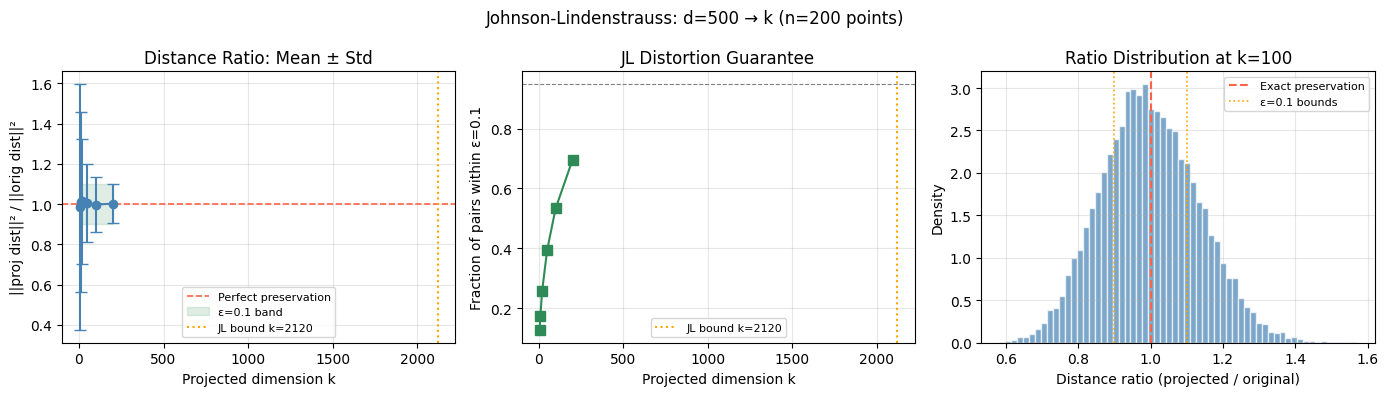

In [4]:
# Johnson-Lindenstrauss: random projection preserves pairwise distances

def random_projection(X, k, seed=42):
    rng_local = np.random.default_rng(seed)
    d = X.shape[1]
    R = rng_local.standard_normal((k, d))
    return (X @ R.T) / np.sqrt(k)

def pairwise_sq_distances(X):
    sq = np.sum(X**2, axis=1)
    D2 = sq[:, None] + sq[None, :] - 2 * X @ X.T
    np.fill_diagonal(D2, 0)
    return np.maximum(D2, 0)

# Generate n points in high-dimensional space
n, d_orig = 200, 500
X_high = rng.standard_normal((n, d_orig))

D2_orig = pairwise_sq_distances(X_high)
orig_dists = D2_orig[np.triu_indices(n, k=1)]

# Project to various k values
k_values = [5, 10, 20, 50, 100, 200]
# JL bound: k >= 4*log(n)/epsilon^2 for epsilon=0.1
epsilon_target = 0.1
k_jl = int(np.ceil(4 * np.log(n) / epsilon_target**2))
print(f"JL bound for n={n}, ε={epsilon_target}: k ≥ {k_jl}")

distortion_stats = []  # (mean_ratio, std_ratio, frac_within_eps)

for k in k_values:
    X_proj = random_projection(X_high, k)
    D2_proj = pairwise_sq_distances(X_proj)
    proj_dists = D2_proj[np.triu_indices(n, k=1)]
    # ratio of projected to original squared distances
    ratio = proj_dists / (orig_dists + 1e-10)
    frac = np.mean((ratio > (1-epsilon_target)) & (ratio < (1+epsilon_target)))
    distortion_stats.append((ratio.mean(), ratio.std(), frac))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: mean ratio vs k
means = [s[0] for s in distortion_stats]
stds = [s[1] for s in distortion_stats]
ax = axes[0]
ax.errorbar(k_values, means, yerr=stds, fmt='o-', color='steelblue',
            capsize=4, linewidth=1.5)
ax.axhline(1.0, color='tomato', linestyle='--', linewidth=1.2, label='Perfect preservation')
ax.fill_between(k_values, 1-epsilon_target, 1+epsilon_target,
                alpha=0.15, color='seagreen', label=f'ε={epsilon_target} band')
ax.axvline(k_jl, color='orange', linestyle=':', linewidth=1.5, label=f'JL bound k={k_jl}')
ax.set_xlabel('Projected dimension k')
ax.set_ylabel('||proj dist||² / ||orig dist||²')
ax.set_title('Distance Ratio: Mean ± Std')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: fraction preserved within epsilon
fracs = [s[2] for s in distortion_stats]
ax = axes[1]
ax.plot(k_values, fracs, 's-', color='seagreen', linewidth=1.5, markersize=7)
ax.axhline(0.95, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(k_jl, color='orange', linestyle=':', linewidth=1.5, label=f'JL bound k={k_jl}')
ax.set_xlabel('Projected dimension k')
ax.set_ylabel(f'Fraction of pairs within ε={epsilon_target}')
ax.set_title('JL Distortion Guarantee')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: distribution of ratios for best k
k_best = 100
X_proj_best = random_projection(X_high, k_best)
D2_best = pairwise_sq_distances(X_proj_best)
ratios_best = D2_best[np.triu_indices(n, k=1)] / (orig_dists + 1e-10)

ax = axes[2]
ax.hist(ratios_best, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(1.0, color='tomato', linestyle='--', linewidth=1.5, label='Exact preservation')
ax.axvline(1-epsilon_target, color='orange', linestyle=':', linewidth=1.2)
ax.axvline(1+epsilon_target, color='orange', linestyle=':', linewidth=1.2, label=f'ε={epsilon_target} bounds')
ax.set_xlabel('Distance ratio (projected / original)')
ax.set_ylabel('Density')
ax.set_title(f'Ratio Distribution at k={k_best}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Johnson-Lindenstrauss: d={d_orig} → k (n={n} points)', fontsize=12)
plt.tight_layout()
plt.savefig('ch240_johnson_lindenstrauss.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Why Random Projections Preserve Inner Products

The JL lemma preserves distances. But why? The proof reduces to a single remarkable fact:

**Fact:** If $\mathbf{r} \sim \mathcal{N}(0, I_d)$ and $\mathbf{u}$ is a fixed unit vector,
then $\mathbf{r}^\top \mathbf{u} \sim \mathcal{N}(0, 1)$ regardless of $d$.

The inner product of a Gaussian vector with any fixed direction is just a standard
normal — the dimension $d$ cancels out entirely. This is the mathematical reason
random projections work: they do not distort the signal, they only add isotropic noise.

More precisely, for a random projection matrix $R$ with i.i.d. $\mathcal{N}(0,1)$ entries,
scaled by $\frac{1}{\sqrt{k}}$:
$$\mathbb{E}\!\left[\langle R\mathbf{x}, R\mathbf{y} \rangle\right] = \langle \mathbf{x}, \mathbf{y} \rangle$$

The projection is an **unbiased estimator** of the inner product. With $k$ rows,
the variance is $O(1/k)$ — concentrating around the true value.

*(This connects directly to ch136 — Dot Product Intuition (Part V) and to ch183 —
SVD (Part VI), where the optimal deterministic projection was computed.)*

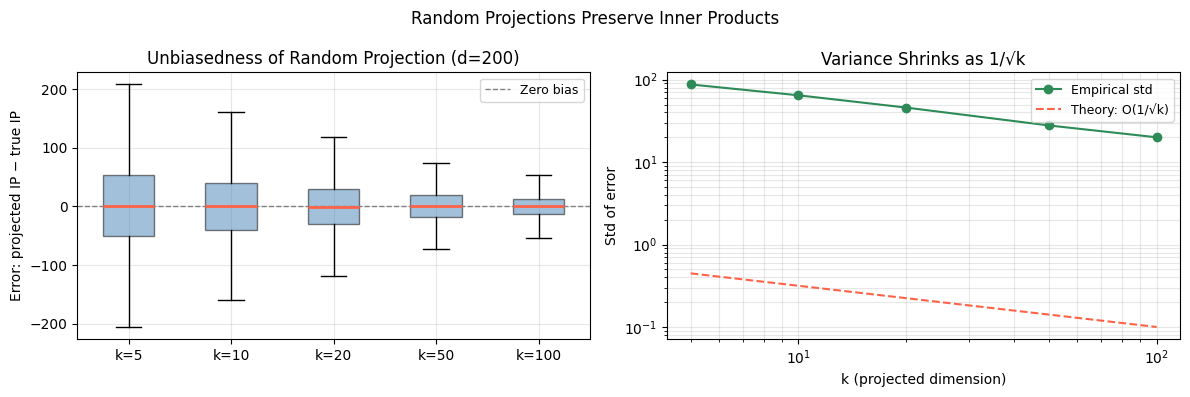

k   | Mean error | Std error | Theory 1/√k
---------------------------------------------
k=  5 | -0.10203    | 87.51449   | 0.44721
k= 10 | +1.06026    | 64.63117   | 0.31623
k= 20 | -0.99780    | 45.85868   | 0.22361
k= 50 | +0.03679    | 27.85244   | 0.14142
k=100 | -0.03552    | 19.99920   | 0.10000


In [5]:
# Verify: random projection preserves inner products (unbiased)

def test_inner_product_preservation(d, k_values, n_pairs=2000):
    results = {}
    for k in k_values:
        errors = []
        for _ in range(n_pairs):
            x = rng.standard_normal(d)
            y = rng.standard_normal(d)
            true_ip = x @ y

            R = rng.standard_normal((k, d)) / np.sqrt(k)
            xp = R @ x
            yp = R @ y
            proj_ip = xp @ yp
            errors.append(proj_ip - true_ip)
        results[k] = np.array(errors)
    return results

d_test = 200
k_test_vals = [5, 10, 20, 50, 100]
results = test_inner_product_preservation(d_test, k_test_vals, n_pairs=3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
positions = range(len(k_test_vals))
data = [results[k] for k in k_test_vals]
bp = ax.boxplot(data, positions=positions, widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='tomato', linewidth=2),
                showfliers=False)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, label='Zero bias')
ax.set_xticks(positions)
ax.set_xticklabels([f'k={k}' for k in k_test_vals])
ax.set_ylabel('Error: projected IP − true IP')
ax.set_title(f'Unbiasedness of Random Projection (d={d_test})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
stds = [results[k].std() for k in k_test_vals]
ax.loglog(k_test_vals, stds, 'o-', color='seagreen', linewidth=1.5, label='Empirical std')
ax.loglog(k_test_vals, [1/np.sqrt(k) for k in k_test_vals], '--',
          color='tomato', linewidth=1.5, label='Theory: O(1/√k)')
ax.set_xlabel('k (projected dimension)')
ax.set_ylabel('Std of error')
ax.set_title('Variance Shrinks as 1/√k')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Random Projections Preserve Inner Products', fontsize=12)
plt.tight_layout()
plt.savefig('ch240_inner_product_preservation.png', dpi=120, bbox_inches='tight')
plt.show()

print("k   | Mean error | Std error | Theory 1/√k")
print("-" * 45)
for k in k_test_vals:
    err = results[k]
    print(f"k={k:3d} | {err.mean():+.5f}    | {err.std():.5f}   | {1/np.sqrt(k):.5f}")

## 6. Implications for Machine Learning Calculus

The high-dimensional geometry we have uncovered explains several widely-observed
phenomena in deep learning:

| Phenomenon | High-Dimensional Explanation |
|---|---|
| Saddle points dominate | In $d$ dims, each critical point has $2^d$ sign-pattern possibilities for Hessian diagonal; uniform → half positive, half negative → saddle *(ch239)* |
| Adam beats SGD in early training | Gradient directions nearly orthogonal → component-wise normalization helps *(ch238)* |
| Random initialization works | JL lemma: random weights preserve signal norms through layers |
| Dropout regularizes | Random projection at each step averages over exponentially many subnetworks |
| Overparameterized models generalize | In high $d$, there are exponentially many directions to route around training points without affecting test geometry |

**The Taylor Series perspective** *(ch219)*: In 1D, $f(x + h) \approx f(x) + hf'(x) + \frac{h^2}{2}f''(x)$.

In $d$ dimensions: $f(\mathbf{x} + \mathbf{h}) \approx f(\mathbf{x}) + \mathbf{h}^\top \nabla f + \frac{1}{2}\mathbf{h}^\top H \mathbf{h}$

The Hessian $H \in \mathbb{R}^{d \times d}$ has $d^2$ entries. For $d = 10^7$ parameters,
storing $H$ exactly requires $10^{14}$ floats — 800 terabytes. This is why second-order
methods *(ch239)* are approximated (LBFGS, K-FAC) rather than computed exactly.

The geometry does not break calculus. It breaks naive implementations of calculus.
Understanding the geometry tells you *which* approximations are principled.

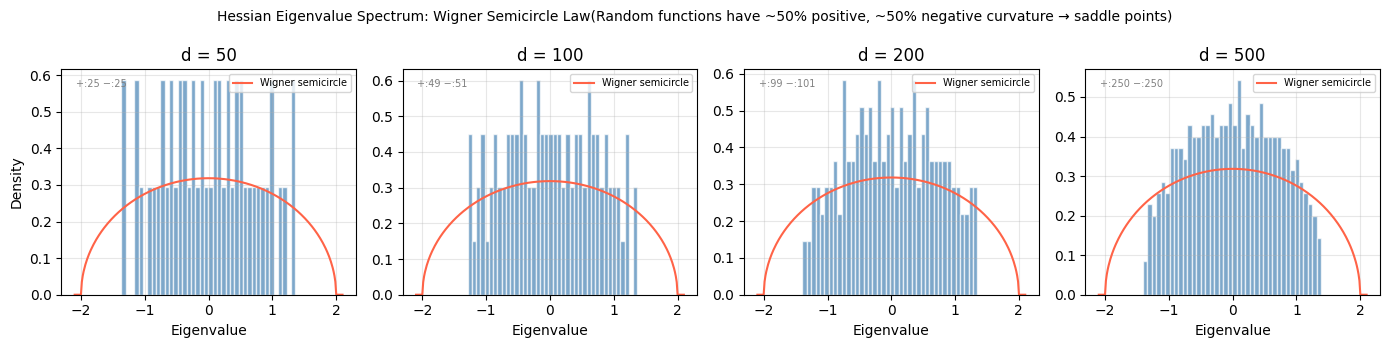

Observation: in high dimensions, random critical points are almost always saddle points.
This is why gradient descent can escape — there is almost always a descent direction.


In [7]:
# Illustrate: Hessian spectrum in high dimensions (random matrix theory)
# For a random function, the Hessian eigenvalue distribution follows the
# Marchenko-Pastur / Wigner semicircle law

def random_symmetric_matrix(d, rng_local):
    A = rng_local.standard_normal((d, d))
    return (A + A.T) / (2 * np.sqrt(d))

dims_hess = [50, 100, 200, 500]
fig, axes = plt.subplots(1, len(dims_hess), figsize=(14, 3.5))

for ax, d in zip(axes, dims_hess):
    H = random_symmetric_matrix(d, rng)
    eigvals = np.linalg.eigvalsh(H)
    ax.hist(eigvals, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')

    # Wigner semicircle: rho(x) = sqrt(4 - x^2) / (2*pi) for |x| <= 2
    x_range = np.linspace(-2.1, 2.1, 300)
    semicircle = np.sqrt(np.maximum(4 - x_range**2, 0)) / (2 * np.pi)
    ax.plot(x_range, semicircle, 'tomato', linewidth=1.5, label='Wigner semicircle')
    ax.set_title(f'd = {d}')
    ax.set_xlabel('Eigenvalue')
    ax.set_ylabel('Density' if d == 50 else '')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    n_pos = np.sum(eigvals > 0)
    n_neg = np.sum(eigvals < 0)
    ax.text(0.05, 0.92, f'+:{n_pos} −:{n_neg}', transform=ax.transAxes,
            fontsize=7, color='gray')

plt.suptitle('Hessian Eigenvalue Spectrum: Wigner Semicircle Law'
             '(Random functions have ~50% positive, ~50% negative curvature → saddle points)', fontsize=10)
plt.tight_layout()
plt.savefig('ch240_hessian_spectrum.png', dpi=120, bbox_inches='tight')
plt.show()
print("Observation: in high dimensions, random critical points are almost always saddle points.")
print("This is why gradient descent can escape — there is almost always a descent direction.")

## 7. Summary

| Concept | Low-d intuition | High-d reality |
|---|---|---|
| Unit ball volume | Grows with radius | Vanishes as $d \to \infty$ |
| Point cloud geometry | Spread out | All points near the surface |
| Nearest neighbor | Meaningful | Degenerates (ratio → 0) |
| Random unit vectors | Can point anywhere | Nearly always orthogonal |
| Gradient norm | Bounded | Grows as $\sqrt{d}$ |
| Hessian eigenvalues | Deterministic curvature | Semicircle distribution; ~50/50 sign |
| Dimensionality reduction | Loses information | JL: preserve to $\epsilon$ with $O(\log n)$ dims |
| Inner products | Exact | Random projection: unbiased, std $O(1/\sqrt{k})$ |

**The central message:** High-dimensional calculus is not different in its rules.
The derivative is still a linear approximation. The gradient still points uphill.
The Hessian still encodes curvature. What changes is the *geometry* those objects
inhabit — and that geometry is profoundly counterintuitive.

Every tool from ch201 onward remains valid. What changes is knowing *which* tool
to reach for, at what cost, and with which approximation.

---

## 8. Part VII Complete

You have traversed the full calculus arc:

| Range | Topic |
|---|---|
| ch201–204 | Motivation, limits, change |
| ch205–208 | Derivatives and automatic differentiation |
| ch209–214 | Gradients, optimization, landscapes |
| ch215–216 | Chain rule and backpropagation |
| ch217–220 | Higher-order: curvature, Taylor, approximation |
| ch221–224 | Integration: analytical, numerical, Monte Carlo |
| ch225–227 | Differential equations and gradient-based learning |
| ch228–230 | Projects: gradient descent, linear regression, logistic regression |
| ch231–240 | Advanced: Newton, Fourier, constraints, convolution, Jacobians, SGD theory, Hessians, high dimensions |

---

## 9. Forward References

The machinery of Part VII feeds directly into the final two Parts:

**Part VIII — Probability (ch241–270)**
- Monte Carlo integration (ch224) is the computational core of probabilistic inference
- Differential equations (ch225) model probability distributions that evolve over time (Fokker-Planck)
- Gradient descent (ch212, ch227) reappears as variational inference

**Part IX — Statistics & Data Science (ch271–300)**
- The optimization methods of ch231–239 underpin ch292 — Optimization Methods
- The JL lemma and random projections connect to ch294 — Dimensionality Reduction
- The Wigner semicircle / Hessian spectrum connects to ch293 — Clustering (spectral methods)
- The full calculus arc culminates in ch300 — End-to-End AI System, where every
  derivative computed, every gradient descended, every Jacobian assembled, traces
  back to the foundations built in these 40 chapters.

*This chapter will reappear explicitly in ch294 — Dimensionality Reduction (Part IX),
where random projections are compared with PCA and autoencoders on real data.*